# 03 — RSU Clustering in Metabolite Space

Three complementary analyses:

1. **RSU-level aggregate** — mean metabolite vector across all foods per RSU, bioactive dims only
2. **RSU dendrogram** — hierarchical clustering of the 12 RSUs
3. **Category-stratified** — aromatics vs aromatics, fermented vs fermented across RSUs

**v0.2 constraint:** Clustering is organizational. Earth system variables are labels, not drivers.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform, pdist
from pathlib import Path
from rsu_loader import load_all_rsus

OUT = Path('../data/metabolites')

In [2]:
rsus = load_all_rsus()

rsu_meta = pd.DataFrame([{
    'region_id': r.region_id,
    'name': r.name,
    'geology': r.geology.parent_material,
    'temp_mean': r.climate.temperature_mean,
    'precip_mean': r.climate.precipitation_mean,
    'fermentation': r.food_system.fermentation_prevalence,
    'industrial': r.culture.industrial_processing_index,
} for r in rsus]).set_index('region_id')

# Full food matrix (region_id, food_name) x metabolite dims
matrix = pd.read_csv('../data/metabolites/rsu_metabolite_matrix.csv', index_col=[0, 1])
print(f"Food matrix: {matrix.shape}")

# Separate macro dims from bioactive/geographic dims
MACRO_DIMS = [
    'primary_metabolites.protein_content',
    'primary_metabolites.lipid_content',
    'primary_metabolites.starch_content',
    'primary_metabolites.fiber_content',
    'primary_metabolites.glucose_concentration',
    'primary_metabolites.energy_kcal',
    'primary_metabolites.saturated_fat_g',
    'primary_metabolites.amino_acid_content',
]
GEO_DIMS = [c for c in matrix.columns if c not in MACRO_DIMS]
print(f"Geographic/bioactive dims: {GEO_DIMS}")

Food matrix: (146, 27)
Geographic/bioactive dims: ['organic_acids.lactic_acid', 'organic_acids.citric_acid', 'organic_acids.malic_acid', 'key_flavor_bioactives.tannin_content', 'organic_acids.acetic_acid', 'umami_compounds.glutamate', 'terpenes.pinene', 'terpenes.linalool', 'primary_metabolites.fructose_concentration', 'primary_metabolites.ascorbic_acid', 'terpenes.limonene', 'key_flavor_bioactives.capsaicinoids', 'terpenes.myrcene', 'primary_metabolites.oleic_acid', 'primary_metabolites.linoleic_acid', 'key_flavor_bioactives.polyphenol_content', 'key_flavor_bioactives.tocopherol_content', 'key_flavor_bioactives.caffeine_concentration', 'umami_compounds.inosinate', 'key_flavor_bioactives.isothiocyanates', 'umami_compounds.guanylate', 'key_flavor_bioactives.hydroxytyrosol', 'key_flavor_bioactives.theobromine_concentration']


---
## 1. RSU-level aggregate vectors

Mean each metabolite dimension across all foods within an RSU.
This captures the overall bioactive character of the regional food system.

In [3]:
# Mean across foods per RSU, ignoring NaN
rsu_matrix = matrix.groupby(level='region_id').mean()
print(f"RSU aggregate matrix: {rsu_matrix.shape}")
rsu_matrix

RSU aggregate matrix: (31, 27)


,primary_metabolites.starch_content,primary_metabolites.lipid_content,primary_metabolites.protein_content,organic_acids.lactic_acid,organic_acids.citric_acid,organic_acids.malic_acid,primary_metabolites.glucose_concentration,key_flavor_bioactives.tannin_content,organic_acids.acetic_acid,umami_compounds.glutamate,...,primary_metabolites.oleic_acid,primary_metabolites.linoleic_acid,key_flavor_bioactives.polyphenol_content,key_flavor_bioactives.tocopherol_content,key_flavor_bioactives.caffeine_concentration,umami_compounds.inosinate,key_flavor_bioactives.isothiocyanates,umami_compounds.guanylate,key_flavor_bioactives.hydroxytyrosol,key_flavor_bioactives.theobromine_concentration
region_id,,,,,,,,,,,,,,,,,,,,,
RSU-01,31.800667,6.901600,12.912800,0.750,2.000000,0.8500,7.710,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-02,19.079667,0.651600,10.184200,NaN,1.500000,0.6500,14.220,400.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-03,23.185500,3.014500,8.017750,7.000,2.250000,1.0000,0.100,4.50,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-04,55.740000,23.848500,14.101667,1.000,NaN,0.4000,3.720,NaN,0.1750,1.950000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-05,23.836000,24.914800,10.844250,7.000,0.500000,0.2400,1.210,NaN,1.2500,0.190000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-06,32.543000,18.870750,19.316400,NaN,NaN,NaN,NaN,NaN,NaN,7.550000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-07,14.690000,10.533000,10.160000,NaN,NaN,NaN,NaN,NaN,NaN,0.320000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-08,44.596000,29.215800,11.600000,NaN,NaN,NaN,NaN,NaN,NaN,1003.350000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-09,67.750667,10.171000,11.337500,NaN,15.500000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Geographic dims only — drop macro cols that just reflect food category
rsu_geo = rsu_matrix[[c for c in GEO_DIMS if c in rsu_matrix.columns]]
rsu_geo = rsu_geo.dropna(how='all', axis=1)  # drop dims with no data at RSU level
print(f"RSU geo matrix: {rsu_geo.shape}")
print(f"Dims: {rsu_geo.columns.tolist()}")
rsu_geo

RSU geo matrix: (31, 23)
Dims: ['organic_acids.lactic_acid', 'organic_acids.citric_acid', 'organic_acids.malic_acid', 'key_flavor_bioactives.tannin_content', 'organic_acids.acetic_acid', 'umami_compounds.glutamate', 'terpenes.pinene', 'terpenes.linalool', 'primary_metabolites.fructose_concentration', 'primary_metabolites.ascorbic_acid', 'terpenes.limonene', 'key_flavor_bioactives.capsaicinoids', 'terpenes.myrcene', 'primary_metabolites.oleic_acid', 'primary_metabolites.linoleic_acid', 'key_flavor_bioactives.polyphenol_content', 'key_flavor_bioactives.tocopherol_content', 'key_flavor_bioactives.caffeine_concentration', 'umami_compounds.inosinate', 'key_flavor_bioactives.isothiocyanates', 'umami_compounds.guanylate', 'key_flavor_bioactives.hydroxytyrosol', 'key_flavor_bioactives.theobromine_concentration']


,organic_acids.lactic_acid,organic_acids.citric_acid,organic_acids.malic_acid,key_flavor_bioactives.tannin_content,organic_acids.acetic_acid,umami_compounds.glutamate,terpenes.pinene,terpenes.linalool,primary_metabolites.fructose_concentration,primary_metabolites.ascorbic_acid,...,primary_metabolites.oleic_acid,primary_metabolites.linoleic_acid,key_flavor_bioactives.polyphenol_content,key_flavor_bioactives.tocopherol_content,key_flavor_bioactives.caffeine_concentration,umami_compounds.inosinate,key_flavor_bioactives.isothiocyanates,umami_compounds.guanylate,key_flavor_bioactives.hydroxytyrosol,key_flavor_bioactives.theobromine_concentration
region_id,,,,,,,,,,,,,,,,,,,,,
RSU-01,0.750,2.000000,0.8500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-02,NaN,1.500000,0.6500,400.00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-03,7.000,2.250000,1.0000,4.50,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-04,1.000,NaN,0.4000,NaN,0.1750,1.950000,6.0,40.000,5.75,0.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-05,7.000,0.500000,0.2400,NaN,1.2500,0.190000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-06,NaN,NaN,NaN,NaN,NaN,7.550000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-07,NaN,NaN,NaN,NaN,NaN,0.320000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-08,NaN,NaN,NaN,NaN,NaN,1003.350000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RSU-09,NaN,15.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2. RSU dendrogram

Cluster the 12 RSUs by their bioactive/geographic metabolite fingerprint.
Column-mean fill used only for distance computation.

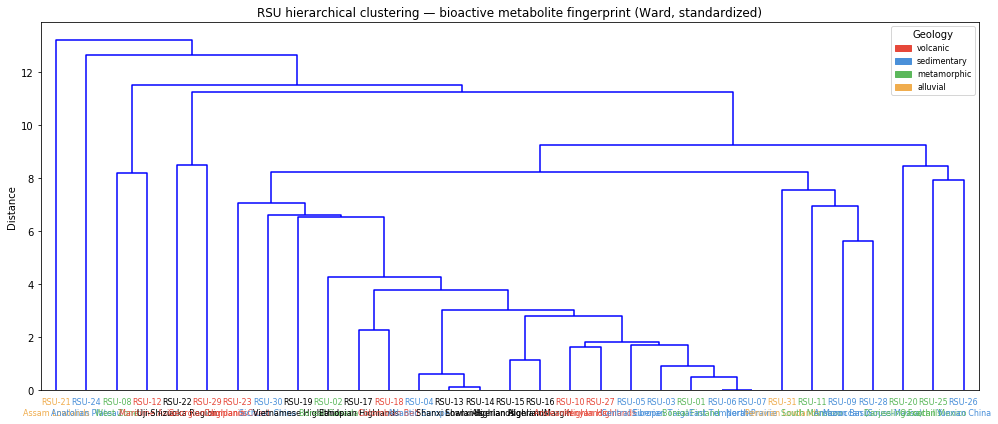

Dims used: ['organic_acids.lactic_acid', 'organic_acids.citric_acid', 'organic_acids.malic_acid', 'key_flavor_bioactives.tannin_content', 'organic_acids.acetic_acid', 'umami_compounds.glutamate', 'terpenes.pinene', 'terpenes.linalool', 'primary_metabolites.fructose_concentration', 'primary_metabolites.ascorbic_acid', 'terpenes.limonene', 'key_flavor_bioactives.capsaicinoids', 'terpenes.myrcene', 'primary_metabolites.oleic_acid', 'primary_metabolites.linoleic_acid', 'key_flavor_bioactives.polyphenol_content', 'key_flavor_bioactives.tocopherol_content', 'key_flavor_bioactives.caffeine_concentration', 'umami_compounds.inosinate', 'key_flavor_bioactives.isothiocyanates', 'umami_compounds.guanylate', 'key_flavor_bioactives.hydroxytyrosol', 'key_flavor_bioactives.theobromine_concentration']


In [5]:
if rsu_geo.shape[1] == 0:
    print("No geographic dims with data. Check RSU JSON files.")
elif len(rsu_geo) < 3:
    print("Need >= 3 RSUs.")
else:
    # Fill missing dims with column mean for distance computation only
    rsu_filled = rsu_geo.apply(lambda col: col.fillna(col.mean()))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(rsu_filled.values)

    Z = linkage(X_scaled, method='ward', metric='euclidean')

    # Labels: region_id + short name
    labels = [f"{rid}\n{rsu_meta.loc[rid, 'name'].split()[0]} {rsu_meta.loc[rid, 'name'].split()[-1]}"
              for rid in rsu_filled.index]

    # Color leaves by geology
    geo_types = rsu_meta.loc[rsu_filled.index, 'geology']
    geo_colors = {'volcanic': '#e6483a', 'sedimentary': '#4a90d9', 'metamorphic': '#5cb85c', 'alluvial': '#f0ad4e'}

    fig, ax = plt.subplots(figsize=(14, 6))
    dend = dendrogram(Z, labels=labels, ax=ax, leaf_rotation=0, leaf_font_size=8,
                      color_threshold=0)

    # Color x-tick labels by geology
    for lbl, tick in zip(ax.get_xticklabels(), dend['leaves']):
        rid = rsu_filled.index[tick]
        lbl.set_color(geo_colors.get(geo_types[rid], 'black'))

    legend_patches = [mpatches.Patch(color=c, label=g) for g, c in geo_colors.items()]
    ax.legend(handles=legend_patches, title='Geology', loc='upper right', fontsize=8)
    ax.set_title('RSU hierarchical clustering — bioactive metabolite fingerprint (Ward, standardized)')
    ax.set_ylabel('Distance')
    plt.tight_layout()
    plt.savefig(OUT / 'rsu_dendrogram.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Dims used: {rsu_filled.columns.tolist()}")

### RSU cluster assignments + earth system overlay

In [6]:
if rsu_geo.shape[1] > 0 and len(rsu_geo) >= 4:
    rsu_filled = rsu_geo.apply(lambda col: col.fillna(col.mean()))
    X_scaled = StandardScaler().fit_transform(rsu_filled.values)

    scores = {}
    for k in range(2, min(len(rsu_geo), 6)):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        scores[k] = silhouette_score(X_scaled, km.fit_predict(X_scaled))

    best_k = max(scores, key=scores.get)
    print(f"Silhouette: { {k: round(v, 3) for k, v in scores.items()} }  ->  best K={best_k}")

    km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    rsu_meta['cluster'] = km.fit_predict(X_scaled)

    print(rsu_meta[['name', 'geology', 'temp_mean', 'fermentation', 'industrial', 'cluster']]
          .sort_values('cluster').to_string())

    print("\nCluster means (earth system):")
    print(rsu_meta.groupby('cluster')[['temp_mean', 'precip_mean', 'fermentation', 'industrial']].mean().round(2))

Silhouette: {2: 0.438, 3: 0.344, 4: 0.358, 5: 0.307}  ->  best K=2
                                             name       geology  temp_mean  fermentation  industrial  cluster
region_id                                                                                                    
RSU-21                             Assam Lowlands      alluvial       24.0          0.70        0.40        0
RSU-01                             Boreal Finland   metamorphic        2.5          0.75        0.40        1
RSU-29                Georgian Caucasus Highlands      volcanic       11.5          0.80        0.30        1
RSU-28         Moroccan Argan Coast (Souss-Massa)   sedimentary       19.5          0.45        0.35        1
RSU-27                           Kenyan Highlands      volcanic       17.0          0.50        0.45        1
RSU-26                               Yunnan China   sedimentary       14.5          0.75        0.35        1
RSU-25                   Oaxacan Highlands Mexico   m

---
## 3. Category-stratified clustering

Compare like with like: aromatics vs aromatics, fermented vs fermented.
Tests H4 (convergent terroir) — do similar climates produce similar flavor chemistry
within the same food category?

In [7]:
# Rebuild food matrix with category column
food_meta = []
for rsu in rsus:
    for food in rsu.staple_foods:
        food_meta.append({'region_id': rsu.region_id, 'food_name': food.name,
                          'category': food.macronutrient_category})

food_meta_df = pd.DataFrame(food_meta).set_index(['region_id', 'food_name'])
full_df = matrix.join(food_meta_df)
full_df.head()

primary_metabolites.starch_content  \
region_id food_name                                                      
RSU-01    rye bread                                             77.162   
          Atlantic salmon                                          NaN   
          pike                                                     NaN   
          cloudberries                                           8.600   
          fermented Baltic herring                               9.640   

                                    primary_metabolites.lipid_content  \
region_id food_name                                                     
RSU-01    rye bread                                             1.908   
          Atlantic salmon                                      13.110   
          pike                                                  0.690   
          cloudberries                                          0.800   
          fermented Baltic herring                             18.000   

                                    primary_metabolites.protein_content  \
region_id food_name                                                       
RSU-01    rye bread                                               8.395   
          Atlantic salmon                                        20.319   
          pike                                                   19.260   
          cloudberries                                            2.400   
          fermented Baltic herring                               14.190   

                                    organic_acids.lactic_acid  \
region_id food_name                                             
RSU-01    rye bread                                      0.75   
          Atlantic salmon                                 NaN   
          pike                                            NaN   
          cloudberries                                    NaN   
          fermented Baltic herring                        NaN   

                                    organic_acids.citric_acid  \
region_id food_name                                             
RSU-01    rye bread                                       NaN   
          Atlantic salmon                                 NaN   
          pike                                            NaN   
          cloudberries                                    2.0   
          fermented Baltic herring                        NaN   

                                    organic_acids.malic_acid  \
region_id food_name                                            
RSU-01    rye bread                                      NaN   
          Atlantic salmon                                NaN   
          pike                                           NaN   
          cloudberries                                  0.85   
          fermented Baltic herring                       NaN   

                                    primary_metabolites.glucose_concentration  \
region_id food_name                                                             
RSU-01    rye bread                                                       NaN   
          Atlantic salmon                                                 NaN   
          pike                                                            NaN   
          cloudberries                                                    NaN   
          fermented Baltic herring                                       7.71   

                                    key_flavor_bioactives.tannin_content  \
region_id food_name                                                        
RSU-01    rye bread                                                  NaN   
          Atlantic salmon                                            NaN   
          pike                                                       NaN   
          cloudberries                                               NaN   
          fermented Baltic herring                                   NaN   

                 


--- aromatic ---


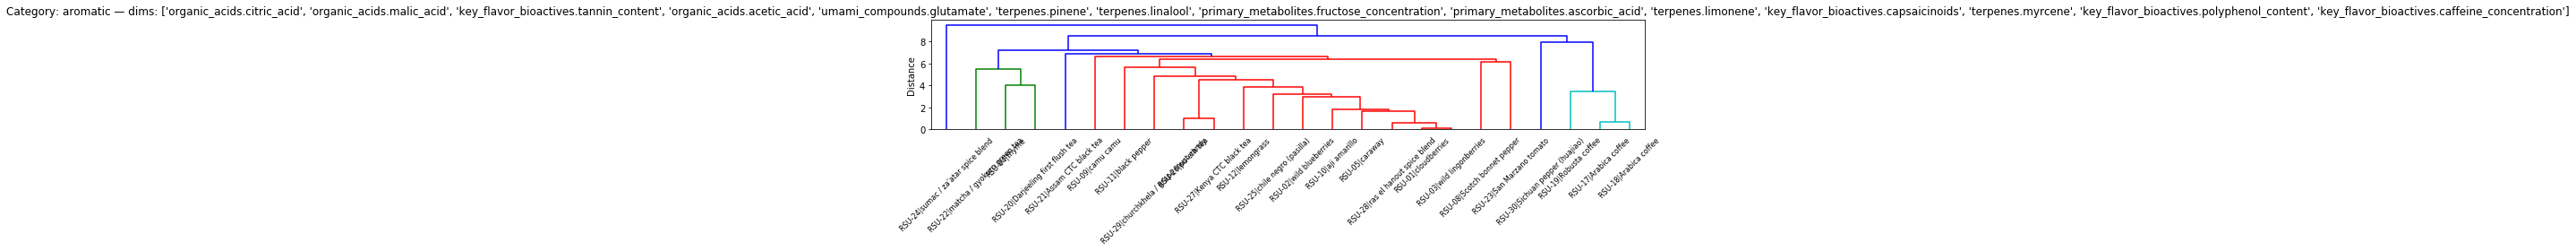


--- fermented ---


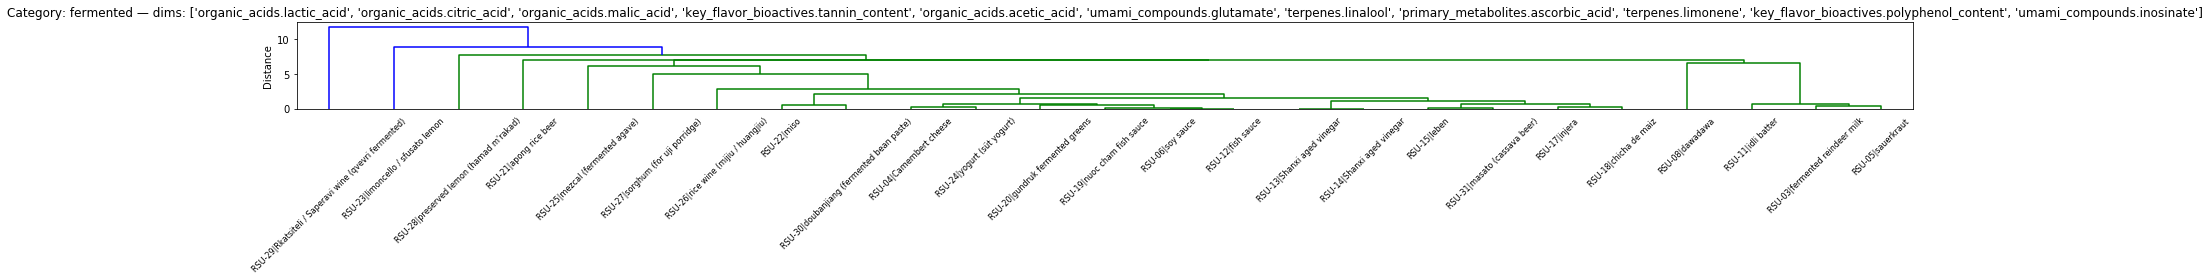


--- protein ---


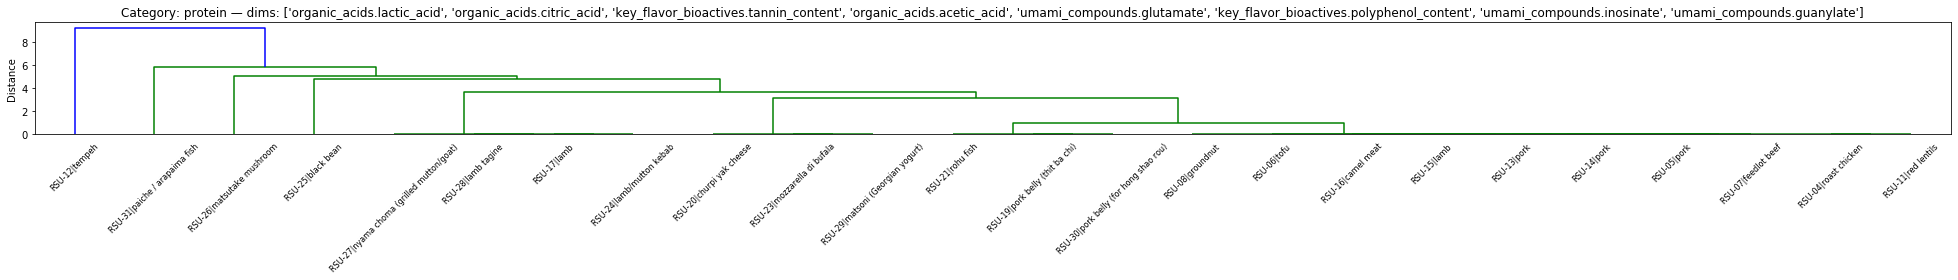


--- fat ---


/home/simonhans/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 


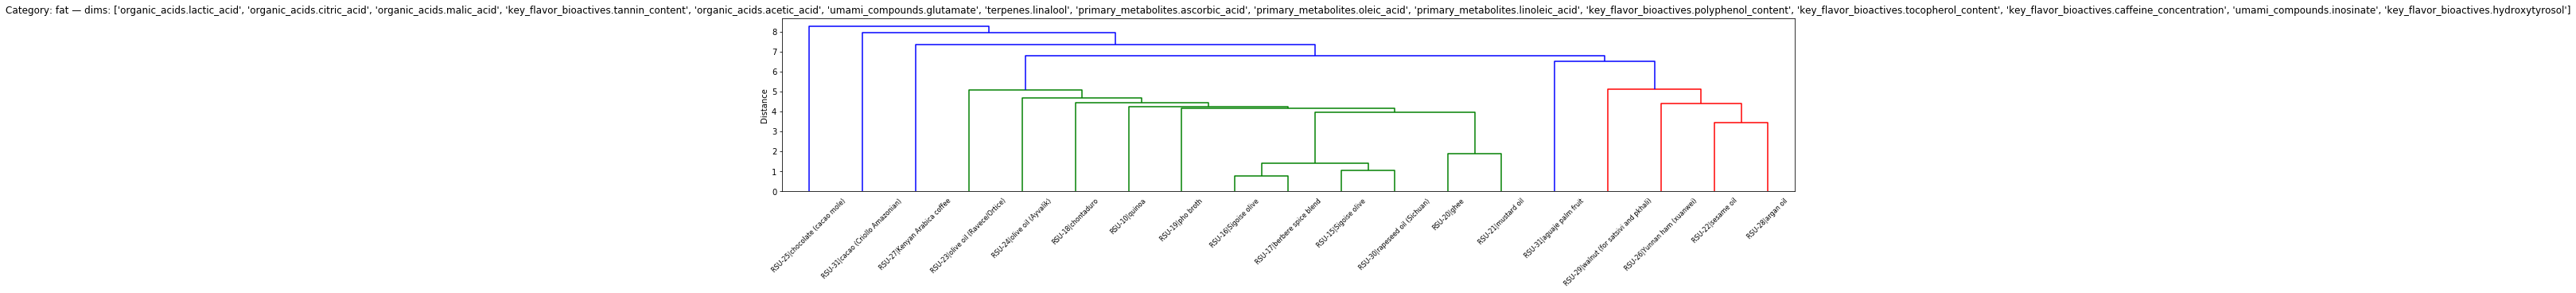


--- carb ---


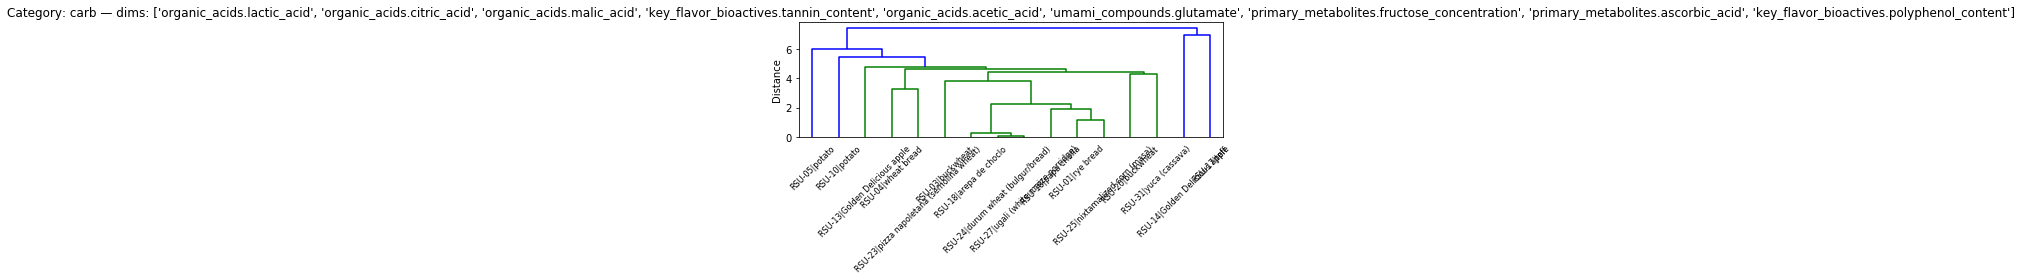

In [8]:
def cluster_category(df, category, dims, min_rows=3):
    """Cluster foods of a given category across RSUs on specified dims."""
    sub = df[df['category'] == category][dims].dropna(how='all')
    if len(sub) < min_rows:
        print(f"  {category}: only {len(sub)} rows with data — skipping")
        return None

    filled = sub.apply(lambda col: col.fillna(col.mean()))
    # Drop all-zero/all-same columns
    filled = filled.loc[:, filled.std() > 0]
    if filled.shape[1] == 0:
        print(f"  {category}: no variance in dims — skipping")
        return None

    X = StandardScaler().fit_transform(filled.values)
    D = pdist(X, metric='euclidean')
    Z = linkage(D, method='ward')

    labels = [f"{r}|{f}" for r, f in sub.index]
    fig, ax = plt.subplots(figsize=(max(8, len(sub) * 1.2), 4))
    dendrogram(Z, labels=labels, ax=ax, leaf_rotation=45, leaf_font_size=8)
    ax.set_title(f'Category: {category} — dims: {filled.columns.tolist()}')
    ax.set_ylabel('Distance')
    plt.tight_layout()
    plt.savefig(OUT / f'cluster_{category}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return sub


for cat in ['aromatic', 'fermented', 'protein', 'fat', 'carb']:
    print(f"\n--- {cat} ---")
    cluster_category(full_df, cat, GEO_DIMS)

---
## 4. PCA on RSU aggregate vectors

2D view of the 12 RSUs in bioactive metabolite space.

Explained variance: [0.148 0.129]


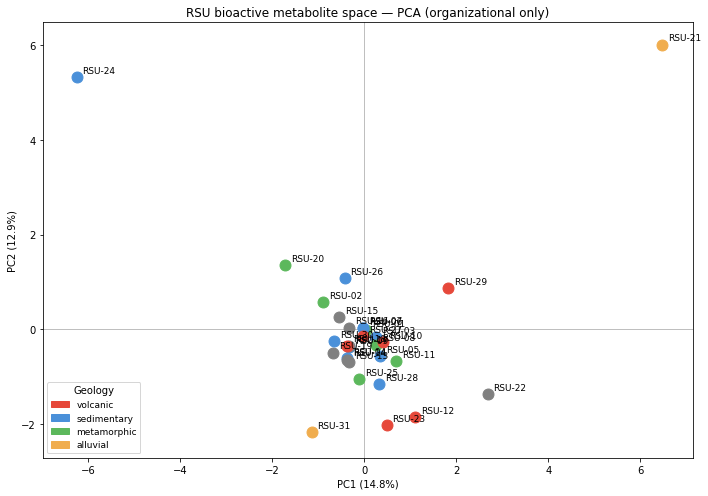


Loadings:
                                                   PC1    PC2
organic_acids.lactic_acid                        0.056 -0.127
organic_acids.citric_acid                       -0.065 -0.074
organic_acids.malic_acid                        -0.339  0.329
key_flavor_bioactives.tannin_content            -0.347  0.226
organic_acids.acetic_acid                        0.348  0.387
umami_compounds.glutamate                        0.053 -0.101
terpenes.pinene                                  0.054 -0.018
terpenes.linalool                               -0.044 -0.071
primary_metabolites.fructose_concentration       0.093  0.112
primary_metabolites.ascorbic_acid                0.344  0.423
terpenes.limonene                               -0.295  0.344
key_flavor_bioactives.capsaicinoids              0.014  0.011
terpenes.myrcene                                 0.079 -0.119
primary_metabolites.oleic_acid                  -0.347 -0.212
primary_metabolites.linoleic_acid                0.208 -0.1

In [9]:
if rsu_geo.shape[1] >= 2 and len(rsu_geo) >= 4:
    rsu_filled = rsu_geo.apply(lambda col: col.fillna(col.mean()))
    X_scaled = StandardScaler().fit_transform(rsu_filled.values)

    pca = PCA(n_components=min(2, X_scaled.shape[1]))
    scores = pca.fit_transform(X_scaled)
    print(f"Explained variance: {pca.explained_variance_ratio_.round(3)}")

    geo_types = rsu_meta.loc[rsu_filled.index, 'geology']
    geo_colors = {'volcanic': '#e6483a', 'sedimentary': '#4a90d9', 'metamorphic': '#5cb85c', 'alluvial': '#f0ad4e'}

    fig, ax = plt.subplots(figsize=(10, 7))
    for i, rid in enumerate(rsu_filled.index):
        color = geo_colors.get(geo_types[rid], 'gray')
        ax.scatter(scores[i, 0], scores[i, 1] if scores.shape[1] > 1 else 0,
                   color=color, s=120, zorder=3)
        ax.annotate(rid, (scores[i, 0], scores[i, 1] if scores.shape[1] > 1 else 0),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)

    legend_patches = [mpatches.Patch(color=c, label=g) for g, c in geo_colors.items()]
    ax.legend(handles=legend_patches, title='Geology', fontsize=9)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})' if scores.shape[1] > 1 else 'PC2 (n/a)')
    ax.set_title('RSU bioactive metabolite space — PCA (organizational only)')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    plt.tight_layout()
    plt.savefig(OUT / 'rsu_pca.png', dpi=150, bbox_inches='tight')
    plt.show()

    loadings = pd.DataFrame(pca.components_.T,
                            index=rsu_filled.columns,
                            columns=[f'PC{i+1}' for i in range(pca.n_components_)])
    print("\nLoadings:")
    print(loadings.round(3).to_string())